In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [41]:
data = pd.read_csv("uber_fares.csv")
data.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [42]:
data.tail()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
199995,42598914,2012-10-28 10:44:41,2.53,2012-10-28 10:44:41 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:13:35,6.55,2014-03-14 01:13:35 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:41:54,31.56,2009-06-29 00:41:54 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:53:55,15.35,2015-05-20 14:53:55 UTC,-73.997124,40.725452,-73.983215,40.695415,1
199999,11951496,2010-05-15 04:06:28,13.28,2010-05-15 04:06:28 UTC,-73.984395,40.720077,-73.985508,40.768793,1


In [43]:
print(data.shape)          # (filas, columnas)
print(data.dtypes)         # tipo de cada columna
print(data.columns.tolist())

(200000, 9)
key                    int64
date                     str
fare_amount          float64
pickup_datetime          str
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object
['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


In [44]:
duplicados_totales = data.duplicated().sum()
duplicados_key = data["key"].duplicated().sum()

print("Duplicados totales:", duplicados_totales)
print("Duplicados en key:", duplicados_key)

Duplicados totales: 0
Duplicados en key: 0


El dataframe consiste de 200k entradas y 9 columnas, de los cuales se tienen lo datos completos de todos salvo las dropout lat y long de 1 viaje.  
 "pickup_datetime    str" <- fechas en string, se va a convertir a datetime
No se encuentran duplicados tampoco.  

In [45]:
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"], errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")

#se buscan diferencias entre date y pickup_datetime
igualdad = (data["date"] == data["pickup_datetime"].dt.tz_localize(None)).all()
print("es igual? "+ str(igualdad))

es igual? True


se teoriza que datetime y pickup datetime son el mismo campo repetido, al confirmarse que es así, se procede a eliminar date y extraer las caracteristicas de datetime

In [46]:
data = data.drop(columns=["date"])
data["year"] = data["pickup_datetime"].dt.year
data["month"] = data["pickup_datetime"].dt.month
data["day"] = data["pickup_datetime"].dt.day
data["hour"] = data["pickup_datetime"].dt.hour
data["weekday"] = data["pickup_datetime"].dt.weekday

se elimina la columna redundante y luego se separa la información presente en pickup_datetime en año, mes, dia, hora y día de semana

In [47]:
data.head(10)
data.tail(10)
data.sample(20, random_state=42)   # ← esto es clave, head() miente

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
119737,187972,5.43,2014-12-08 23:23:23+00:00,-74.000458,40.723990,-73.989682,40.725797,1,2014,12,8,23,0
72272,4242034,49.32,2012-09-02 21:58:45+00:00,0.000000,0.000000,0.000000,0.000000,5,2012,9,2,21,6
158154,42897898,4.96,2010-06-24 18:12:42+00:00,-73.955315,40.779068,-73.970558,40.764650,5,2010,6,24,18,3
65426,16700122,33.23,2012-11-14 20:57:33+00:00,-73.870920,40.773705,-73.964346,40.797100,3,2012,11,14,20,2
30074,13592810,5.00,2011-09-19 08:00:52+00:00,-73.992195,40.748958,-73.987078,40.743065,1,2011,9,19,8,0
23677,8457062,12.99,2013-12-04 15:40:58+00:00,-73.981912,40.748837,-73.982935,40.760280,6,2013,12,4,15,2
134858,12017205,14.50,2014-02-12 13:01:52+00:00,-74.008390,40.745527,-73.990328,40.747882,1,2014,2,12,13,2
176418,24180810,12.47,2012-03-10 01:11:48+00:00,-73.986081,40.722661,-73.958910,40.716867,1,2012,3,10,1,5
132467,15859996,4.48,2009-08-22 22:15:07+00:00,-73.869032,40.773432,-73.870828,40.770777,1,2009,8,22,22,5
4082,35638949,8.42,2010-03-21 21:47:53+00:00,-73.953788,40.771198,-73.976303,40.758948,3,2010,3,21,21,6


In [48]:
data.describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2.771250e+07,11.362915,-72.527638,39.935885,-72.525292,39.923890,1.684535,2011.742435,6.281845,15.704745,13.492565,3.048295
std,1.601382e+07,9.943248,11.437787,7.720539,13.117408,6.794829,1.385997,1.856392,3.438944,8.687452,6.513314,1.946947
min,1.000000e+00,1.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
1%,5.539115e+05,2.950000,-74.014402,0.000000,-74.015288,0.000000,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000
5%,2.723455e+06,3.940000,-74.006838,40.701801,-74.007460,40.686410,1.000000,2009.000000,1.000000,2.000000,1.000000,0.000000
25%,1.382535e+07,5.970000,-73.992065,40.734796,-73.991407,40.733823,1.000000,2010.000000,3.000000,8.000000,9.000000,1.000000
50%,2.774550e+07,8.430000,-73.981823,40.752592,-73.980093,40.753042,1.000000,2012.000000,6.000000,16.000000,14.000000,3.000000
75%,4.155530e+07,12.660000,-73.967154,40.767158,-73.963658,40.768001,2.000000,2013.000000,9.000000,23.000000,19.000000,5.000000
95%,5.265728e+07,30.300000,-73.871200,40.787702,-73.874212,40.793744,5.000000,2015.000000,12.000000,29.000000,22.000000,6.000000


se encuentra un nan entre 200k de entradas, se toma la decisión de eliminarlo para ya que es muy poca info la que se pierde.

In [49]:
data = data.dropna()
len(data)

199999

Se pueden apreciar valores extremos tanto de latitudes y longitudes, y se sabe que las latitudes se cuentan de -90 a 90 y las longitudes de -180 a 180, así que se filtraran todos los datos que posean coordenadas inexistentes, ya que tambien se consideran que son medidas erroneas y van a afectar la capacidad del modelo de predecir viajes reales.

In [50]:
print(data.shape)
data = data[
    (data["pickup_latitude"].between(-90, 90)) &
    (data["pickup_longitude"].between(-180, 180)) &
    (data["dropoff_latitude"].between(-90, 90)) &
    (data["dropoff_longitude"].between(-180, 180))
]
print(data.shape)

(199999, 13)
(199987, 13)


Se opta por eliminar la columna date al ser identica a la pickup_datetime y luego se extraen año, mes, día, hora y día de la semana de pickup_datetime

mirando el describe se logra ver que en fare_amount, el 99% de los datos tienen valores menores a 54usd, mientras que hay un 1% de viajes con montos más llegando a un máximo de 503usd. 
en pasenger_count se puede ver que hay un viaje con más de doscientos pasajeros, se asume que es un error de input, se estudiará esa entry mejor y se determinará que hacer con ella.

In [51]:
#se usó 100usd cómo medida de "outlier" sólo por elegir un número alto para mirar los datos, no hubo 
caros = data[data["fare_amount"]>100]
caros

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
880,41936982,104.69,2013-06-18 15:39:29+00:00,-73.777117,40.645058,-74.155763,40.579618,2,2013,6,18,15,1
2053,31333682,110.78,2014-11-01 08:47:35+00:00,-73.951227,40.778753,-73.949938,40.778149,1,2014,11,1,8,5
4292,33491441,324.41,2014-10-24 20:20:20+00:00,0.000000,0.000000,0.000000,0.000000,3,2014,10,24,20,4
5968,28138818,107.34,2011-05-06 00:44:41+00:00,-73.752265,40.923303,-73.752270,40.923303,1,2011,5,6,0,4
6613,28579349,152.15,2013-05-03 10:03:08+00:00,0.000000,0.000000,0.000000,0.000000,1,2013,5,3,10,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
194454,34209729,130.25,2013-11-22 13:09:44+00:00,-73.982272,40.763447,-74.177182,40.695032,1,2013,11,22,13,4
196616,53659256,104.20,2014-02-02 04:40:23+00:00,-73.984697,40.749896,-74.045293,40.973143,2,2014,2,2,4,6
196647,13085828,196.32,2010-08-19 16:50:58+00:00,-73.952994,40.736298,-73.952994,40.736298,1,2010,8,19,16,3
197428,23637589,100.38,2012-10-17 20:43:12+00:00,-73.985117,40.757527,-74.209528,40.807877,1,2012,10,17,20,2


In [52]:
print(data["passenger_count"].value_counts().sort_index())

passenger_count
0         708
1      138416
2       29427
3        8881
4        4275
5       14008
6        4271
208         1
Name: count, dtype: int64


passenger_count tiene viajes con 0 pasajeros y 208, lo cuál tambien suena a posibles errores en el dataset. 6 se considera un número incómodo para viajar, pero plausible dentro de todo, mientras que viajes con 0 o 200 son considerados un error en el dataset, y tambien eliminados para no comprometer la calidad del modelo.

In [53]:
data = data[(data["passenger_count"] > 0) & (data["passenger_count"] <= 6)].copy()
print(data["passenger_count"].value_counts().sort_index())

passenger_count
1    138416
2     29427
3      8881
4      4275
5     14008
6      4271
Name: count, dtype: int64


para entender un poco mejor el dataset, se hará un mapa interactivo de los pickup

In [54]:
long = data[data["pickup_longitude"] > 35]
long.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
count,1.020000e+02,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.0,102.0,102.000000,102.000000,102.000000
mean,2.761179e+07,13.906863,40.748866,-73.966868,40.753773,-73.978994,2.215686,2013.0,5.0,23.470588,13.931373,3.745098
std,1.704106e+07,11.783365,0.032982,0.049380,0.030267,0.020037,1.875467,0.0,0.0,1.800472,6.424365,1.487148
min,5.827370e+05,2.710000,40.643332,-74.015515,40.646770,-74.015750,1.000000,2013.0,5.0,16.000000,0.000000,0.000000
25%,1.345823e+07,6.635000,40.731266,-73.993150,40.738116,-73.993693,1.000000,2013.0,5.0,23.000000,10.250000,3.000000
50%,2.556742e+07,9.395000,40.753122,-73.981239,40.757545,-73.980613,1.000000,2013.0,5.0,24.000000,15.000000,4.000000
75%,4.460037e+07,14.725000,40.771924,-73.962075,40.772414,-73.966523,3.000000,2013.0,5.0,25.000000,19.000000,5.000000
max,5.531227e+07,57.150000,40.808425,-73.776860,40.831932,-73.896347,6.000000,2013.0,5.0,26.000000,23.000000,6.000000


In [55]:
import folium

# Centro aproximado del mapa usando el promedio de coordenadas
centro_lat = data["pickup_latitude"].mean()
centro_lon = data["pickup_longitude"].mean()

mapa = folium.Map(location=[centro_lat, centro_lon], zoom_start=11)

# Si hay muchos puntos, conviene usar una muestra
muestra = data.sample(500, random_state=42)

for _, row in muestra.iterrows():
    folium.CircleMarker(
        location=[row["pickup_latitude"], row["pickup_longitude"]],
        radius=2,
        fill=True
    ).add_to(mapa)

mapa

se observa en el mapa dos cosas, primero que los viajes del dataset coinciden todos con viajes hechos en NYC, segundo que por algún motivo hay valores en long 0 y lat 0, lo cuál es imposible ya que serían tomados en medio del agua. Se opta por eliminar los 0.0;0.0 ya que se los considera un error en el dataset.

In [56]:
data = data.drop(
    data[
        (data["dropoff_latitude"]  == 0) |
        (data["dropoff_longitude"] == 0) |
        (data["pickup_latitude"]   == 0) |
        (data["pickup_longitude"]  == 0) ].index
)
data

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,weekday
0,24238194,8.47,2015-05-07 19:50:00+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,7.60,2009-07-17 20:00:04+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,44984355,12.65,2009-08-24 21:49:07+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,25894730,5.01,2009-06-26 08:17:45+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,17610152,15.64,2014-08-28 17:46:18+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2.53,2012-10-28 10:44:41+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6
199996,16382965,6.55,2014-03-14 01:13:35+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4
199997,27804658,31.56,2009-06-29 00:41:54+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0
199998,20259894,15.35,2015-05-20 14:53:55+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2


# Graficos:

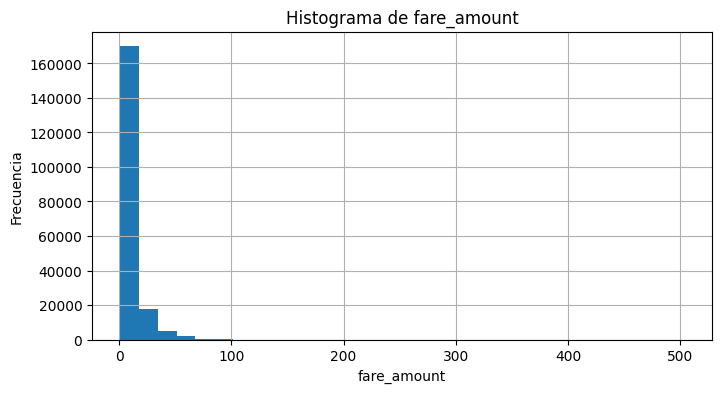

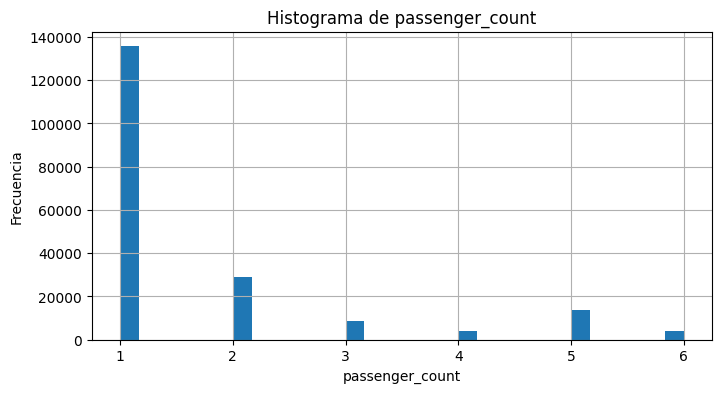

In [57]:
#se generan histogramas de a pares para más claridad
columnas = [
    "fare_amount",
    "passenger_count",
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    data[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

se puede apreciar una gran preferencia para los viajes individuales, se asume que además la gran mayoría de viajes son "cortos" ya que la distribución de los fares está fuertemente sesgada hacia la derecha

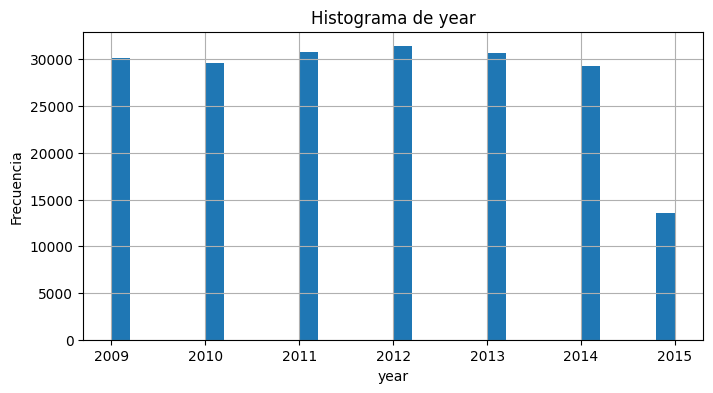

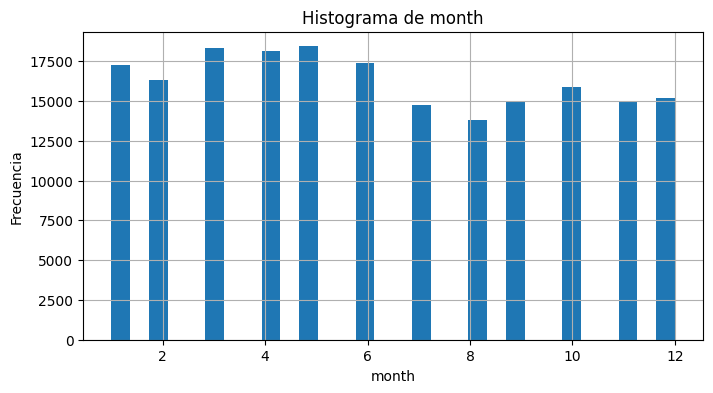

In [58]:
columnas = [
    "year",
    "month",
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    data[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

acá se ve una fuerte caida de viajes en 2015, lo cual se debe a que el dataset llega hasta mediados de 2015. teniendo eso en cuenta, se regenera el analisis de viajes por mes pero excluyendo los viajes de 2015.

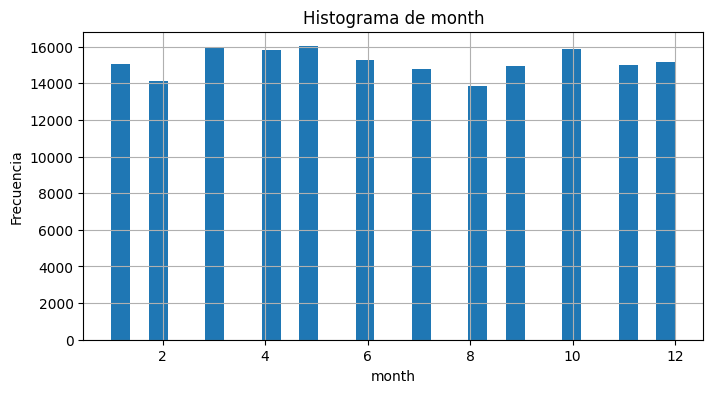

In [59]:
data_2014 = data[data["year"] < 2015]

columnas = [
    "month",
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    data_2014[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Ahora si, se puede ver que en Marzo suele haber un aumento en la cantidad de viajes que dura por tres meses, luego un pequeño descenso que dura desde Junio hasta Agosto y en Septiembre y octubre vuelven a incrementar los viajes hasta noviembre. Se puede apreciar que en EEUU (dónde la mayoría de los viajes de este dataset son) es verano entre Junio y Septiembre, así que se puede teorizar que la baja de viajes entre esos meses podría ser por la gente que elige vacacionar o estudiantes que no tienen que ir a la universidad/escuela.

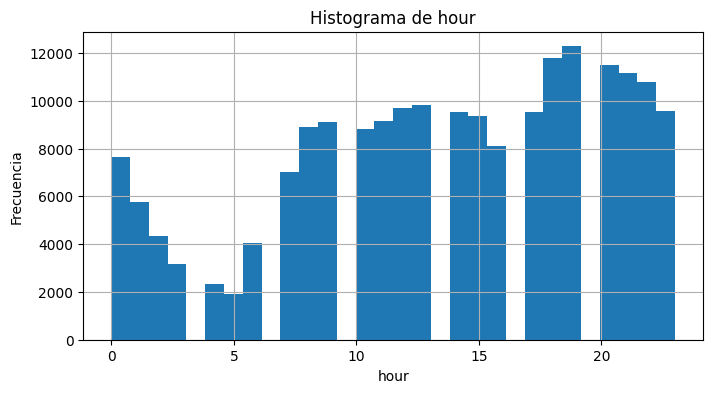

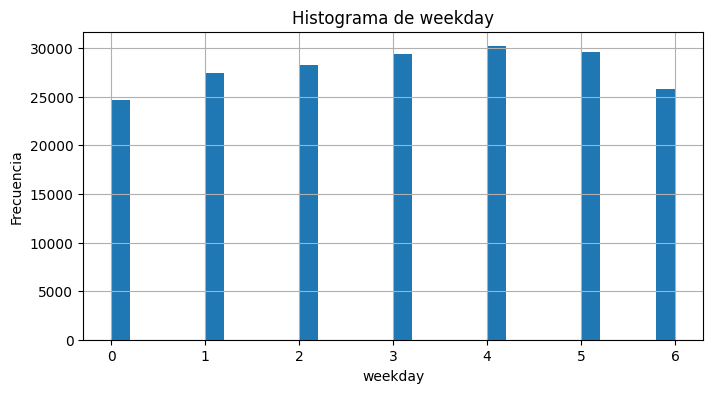

In [60]:
columnas = [
    "hour",
    "weekday"
]

for col in columnas:
    plt.figure(figsize=(8, 4))
    data[col].hist(bins=30)
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

Acá se puede notar que la mayoría de viajes se dan entre el atardecer y la noche, antes de la madrugada, y que los últimos días de la semana son en los que más se solicitan viajes.

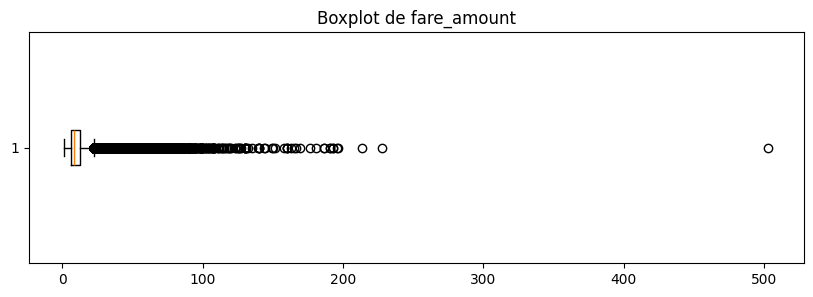

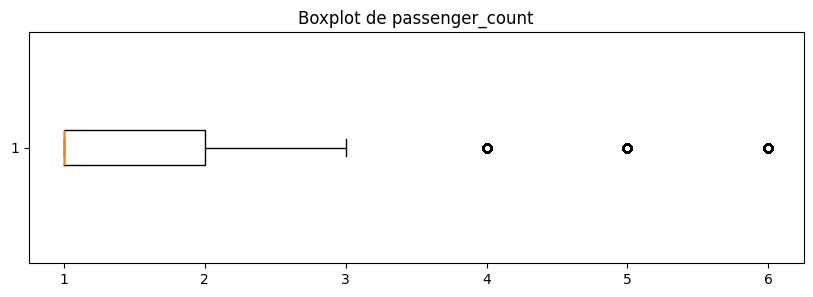

In [61]:
#se genera un boxplot de cada columna relevante
for col in ["fare_amount", "passenger_count"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

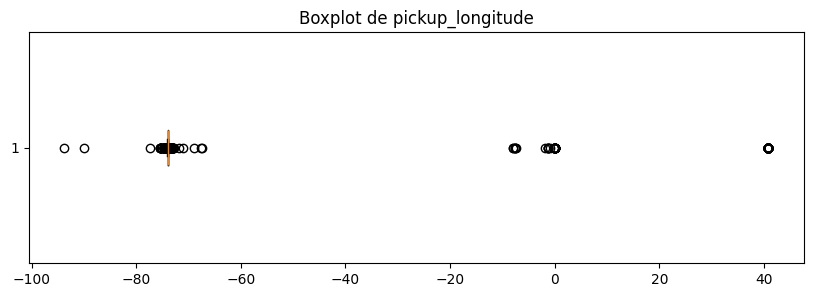

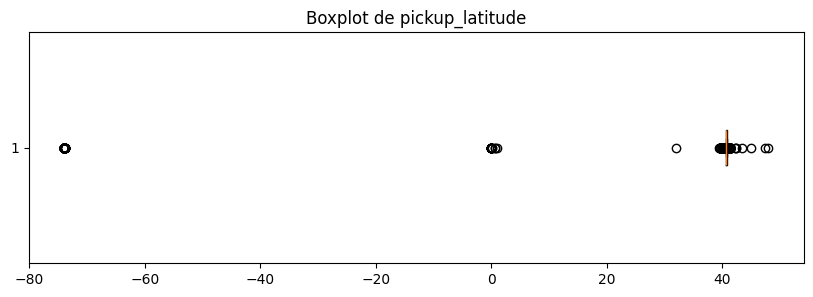

In [62]:
#se genera un boxplot de cada columna relevante
for col in ["pickup_longitude", "pickup_latitude"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

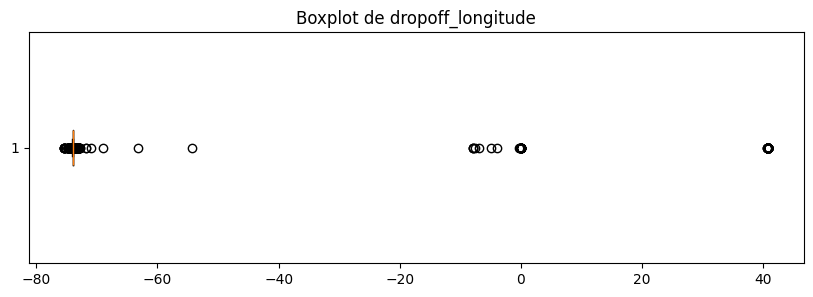

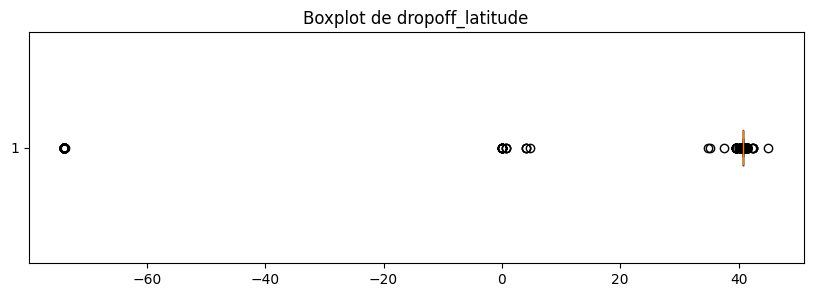

In [63]:
#se genera un boxplot de cada columna relevante
for col in ["dropoff_longitude", "dropoff_latitude"]:
    plt.figure(figsize=(10, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.show()

se siguen observando entradas extrañas en cuanto al dataset, de nuevo demasiado cercanas a 0.

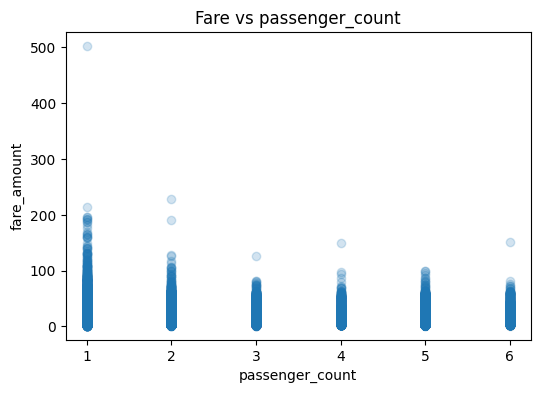

In [64]:
plt.figure(figsize=(6, 4))
plt.scatter(data["passenger_count"], data["fare_amount"], alpha=0.2)
plt.title("Fare vs passenger_count")
plt.xlabel("passenger_count")
plt.ylabel("fare_amount")
plt.show()

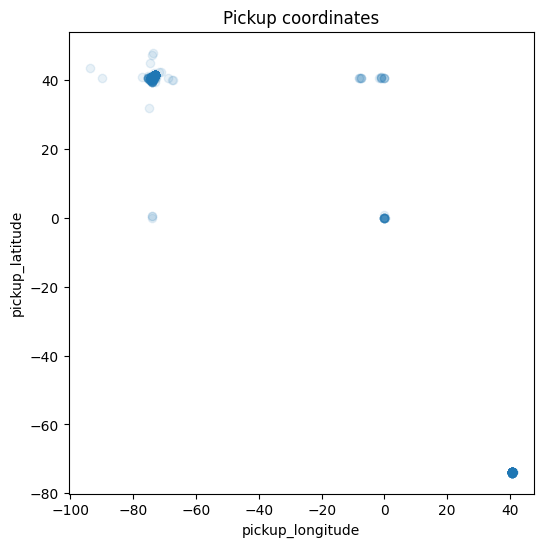

In [65]:
plt.figure(figsize=(6, 6))
plt.scatter(data["pickup_longitude"], data["pickup_latitude"], alpha=0.1)
plt.title("Pickup coordinates")
plt.xlabel("pickup_longitude")
plt.ylabel("pickup_latitude")
plt.show()

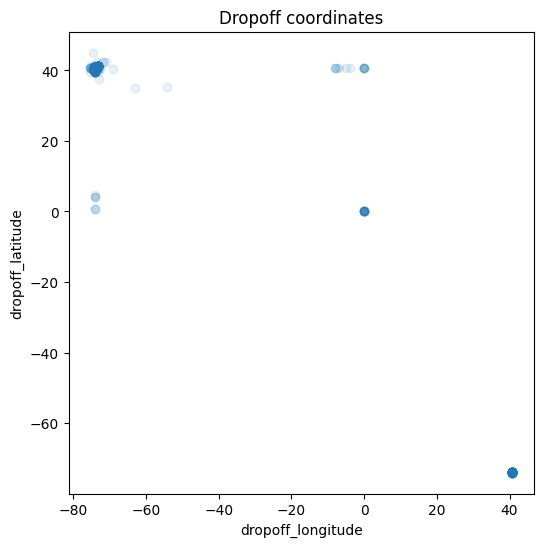

In [66]:
plt.figure(figsize=(6, 6))
plt.scatter(data["dropoff_longitude"], data["dropoff_latitude"], alpha=0.1)
plt.title("Dropoff coordinates")
plt.xlabel("dropoff_longitude")
plt.ylabel("dropoff_latitude")
plt.show()

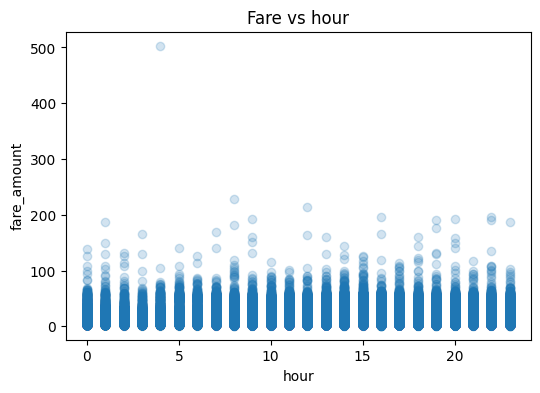

In [67]:
plt.figure(figsize=(6, 4))
plt.scatter(data["hour"], data["fare_amount"], alpha=0.2)
plt.title("Fare vs hour")
plt.xlabel("hour")
plt.ylabel("fare_amount")
plt.show()

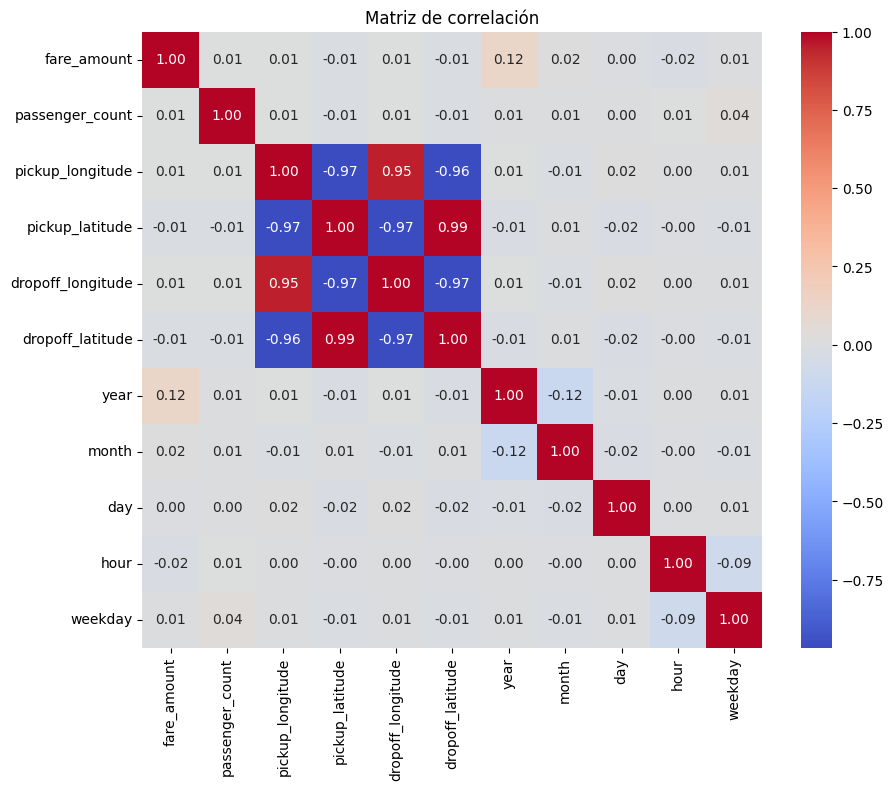

In [68]:
corr_cols = [
    "fare_amount",
    "passenger_count",
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "year",
    "month",
    "day",
    "hour",
    "weekday"
]

corr = data[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()